# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "Trần Tất Nguyên"  # TODO: Họ và tên
STUDENT_ID = "31251020719"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Trần Tất Nguyên (31251020719)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: /Users/nguyentran0703/mliot-pyml-2026-hw/week02/numpy-pandas-eda-hw/data/automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
# TODO N1
shifted_logits = logits - np.max(logits, axis = 1, keepdims = True)
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / np.sum(exp_logits, axis = 1, keepdims = True)
predicted_classes = np.argmax(class_probabilities, axis = 1)
confidence_scores = np.max(class_probabilities, axis=1)




In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
# TODO N2
train_feature_mean = np.mean(X_train, axis = 0)
train_feature_std = np.std(X_train, axis = 0)
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
# TODO N3
correct_mask = predicted_classes == true_labels
high_confidence_mask = confidence_scores >= confidence_threshold
review_mask = (~correct_mask) | (~high_confidence_mask)
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
augmented_batch = normalized_batch[:,:,::-1,:].copy()
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

* Mỗi dòng đại xe cho một mẫu xe trong bộ 1985 Auto Imports

* Kí hiệu missing value trong CSV là "?"

* "Symboling" là mức đánh giá rủi ro bảo hiểm của xe (giá trị từ -3 đến 3)

<!-- Viết câu trả lời tại đây. -->

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [13]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH, keep_default_na=False)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == "?").sum().sum()

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [14]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [15]:
# TODO D2
df_clean = raw_df.replace("?", np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
missing_by_column = df_clean.isna().sum()

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

* Vì mỗi cột đều có phân phối và ý nghĩa khác nhau. Nếu fill một cách bừa bãi sẽ gây sai lệch phân phối dữ liệu cũng như ý nghĩa, tương quan giữa các biến

* Với biến price, em ưu tiên drop các dòng bị thiếu vì: Thứ nhất, đây là một trong 6 biến định lượng trọng tâm của bài. Thứ hai, tỷ lệ thiếu ở cột price là tương đối thấp (4 / 205 = ~2%) nên có thể drop được mà không ảnh hưởng lớn đến phân tích về sau. Đặt trường hợp khi fill bằng mean hoặc median, điều này dẫn đến khả năng hiểu sai các phân tích về giá

* Biến normalized_losses thiếu nhiều dữ liệu (41 / 205 = ~20%) nên các thống kê liên quan đến cột này sẽ kém tin cậy hơn, dễ bị bias hơn và không là một đại diện tốt cho dataset nếu dùng biến này để phân tích trọng tâm
<!-- Viết 3--6 câu tại đây. -->

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [16]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [17]:
# TODO D3
analysis_df = df_clean[AUTO_FEATURES].dropna()
X_auto = analysis_df.to_numpy(dtype=np.float64)
auto_feature_mean = X_auto.mean(axis=0)
auto_feature_std = X_auto.std(axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [18]:
# TODO D4
price_index = AUTO_FEATURES.index("price")
price_values = X_auto[:, price_index]
price_z = (price_values - price_values.mean()) / price_values.std()
price_outlier_mask = np.abs(price_z) > 2
price_outliers = analysis_df[price_outlier_mask]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [19]:
# TODO D5
engine_price_corr = np.corrcoef(analysis_df["engine_size"].to_numpy(), analysis_df["price"].to_numpy())[0, 1]
price_by_body_style = (
    df_clean[["body_style", "price"]]
    .dropna(subset=["price"])
    .groupby("body_style")["price"]
    .mean()
    .sort_index()
)


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

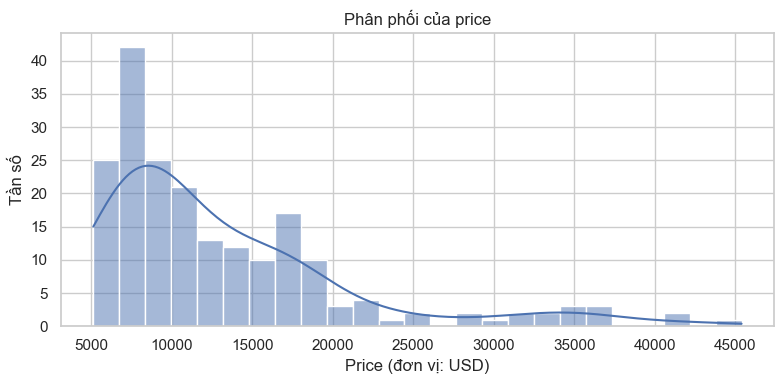

In [20]:
# TODO M2.1: histogram/KDE của price
price_series = df_clean["price"].dropna()
plt.figure(figsize=(8, 4))
sns.histplot(price_series, bins=25, kde=True)
plt.title("Phân phối của price")
plt.xlabel("Price (đơn vị: USD)")
plt.ylabel("Tần số")
plt.tight_layout()
plt.show()

**Nhận xét:** 
Phân phối của price lệch phải cho thấy phần lớn xe nằm ở phân khúc giá thấp đến trung bình. Price tập trung nhiều nhất quanh mức giá từ 5000 USD đến 10000 USD
<!-- 1--2 câu -->

## M2.2 Dataset có cân bằng theo body style không?

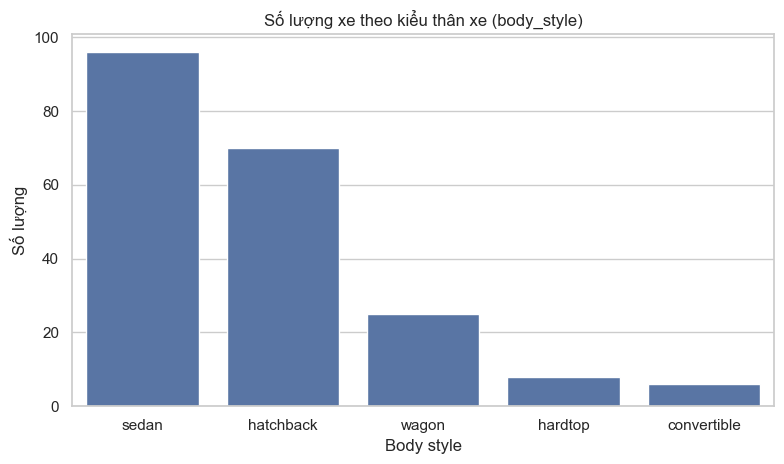

In [21]:
# TODO M2.2: countplot của body_style
plt.figure(figsize=(8, 4.8))
sns.countplot(data=df_clean, x="body_style", order=df_clean["body_style"].value_counts().index)
plt.title("Số lượng xe theo kiểu thân xe (body_style)")
plt.xlabel("Body style")
plt.ylabel("Số lượng")
plt.tight_layout()
plt.show()

**Nhận xét:** Bộ dữ liệu không cân bằng theo body style. Có 5 loại kiểu thân xe, trong đó sedan chiếm số lượng nhiều nhất và thấp nhất là convertible
<!-- 1--2 câu -->

## M2.3 Price khác nhau theo body style ra sao?

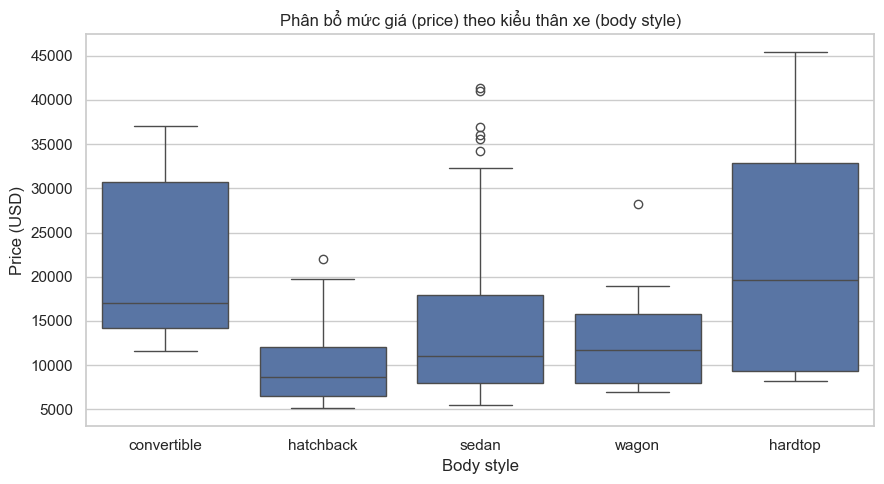

In [22]:
# TODO M2.3: boxplot price theo body_style
plot_df = df_clean[["body_style", "price"]].dropna(subset=["price"])
plt.figure(figsize=(9, 5))
sns.boxplot(data=plot_df, x="body_style", y="price")
plt.title("Phân bổ mức giá (price) theo kiểu thân xe (body style)")
plt.xlabel("Body style")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()

**Nhận xét:**
Sedan có khoảng giá trải rộng nhất (từ nhóm giá thấp đến khá cao) nên đây là kiểu thân xe đa dạng về phân khúc. Trong khi đó hatchback và wagon tập trung nhiều hơn ở nhóm giá thấp đến trung bình.
<!-- 1--2 câu -->

## M2.4 Engine size liên quan thế nào tới price?

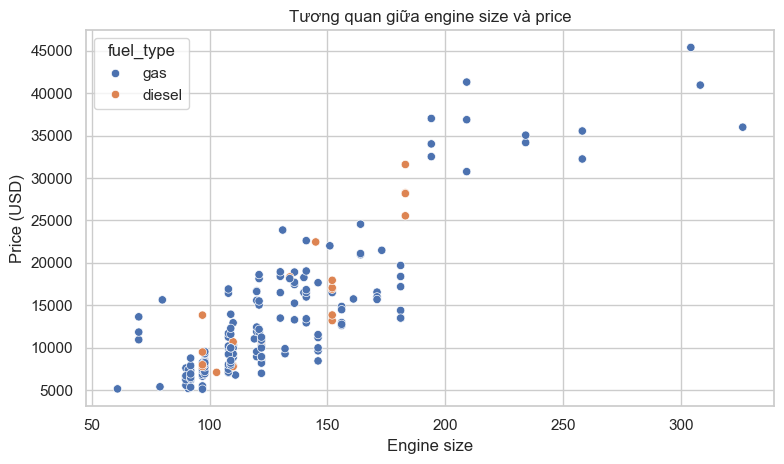

In [23]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
plot_df = df_clean[["engine_size", "price", "fuel_type"]].dropna(subset=["engine_size", "price"])
plt.figure(figsize=(8, 4.8))
sns.scatterplot(data=plot_df, x="engine_size", y="price", hue="fuel_type")
plt.title("Tương quan giữa engine size và price")
plt.xlabel("Engine size")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()

**Nhận xét:** 
Biểu đồ scatter cho thấy engine size và price có tương quan dương khá rõ. Xe có động cơ lớn hơn thường đi kèm giá cao hơn và ngược lại. Song, các điểm dữ liệu không nằm hoàn toàn trên một đường thẳng nên ngoài engine size vẫn còn những yếu tố khác ảnh hưởng đến giá như hãng xe, kiểu thân xe hoặc loại nhiên liệu...
<!-- 1--2 câu -->

## M2.5 Các feature numeric tương quan ra sao?

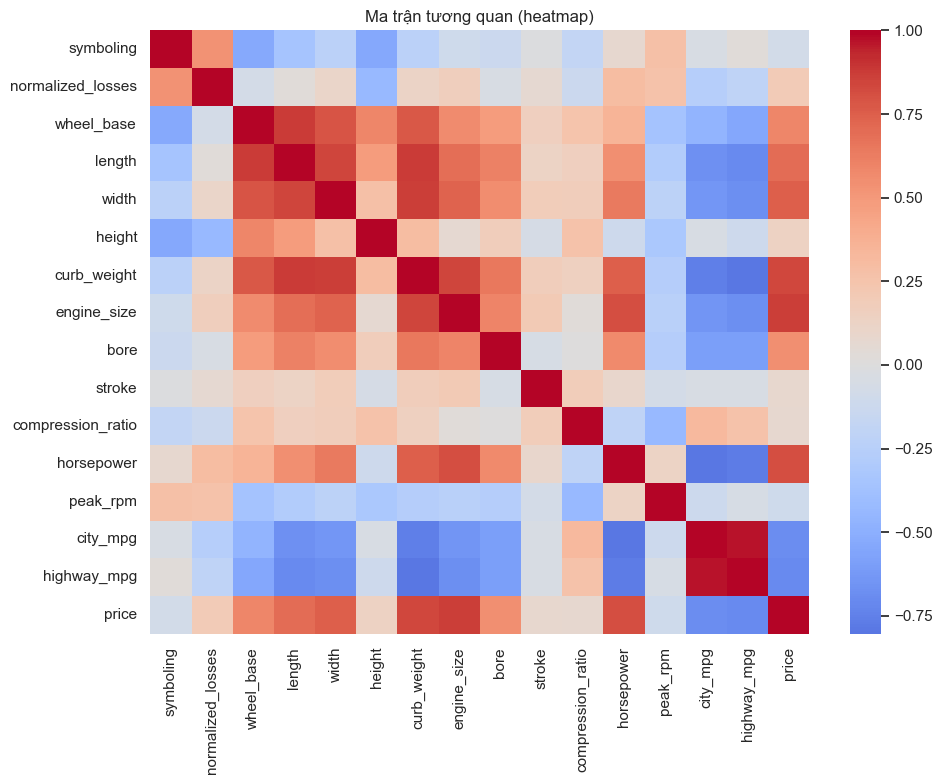

In [24]:
# TODO M2.5: correlation heatmap
numeric_df = df_clean.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
corr = numeric_df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Ma trận tương quan (heatmap)")
plt.tight_layout()
plt.show()

**Nhận xét:** 
Heatmap cho thấy price tương quan dương mạnh với các biến như engine size, horse power và curb weight. Điều này nghĩa là xe có mã lực mạnh hơn và nặng hơn thường đắt hơn. Ngược lại, city_mpg và highway_mpg thường có xu hướng tương quan âm với price, curb weight, horse power. Điều này cho thấy xe lớn, mã lực mạnh và nặng thì thường tốn nhiên liệu hơn và giá  cao hơn
<!-- 1--2 câu -->

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

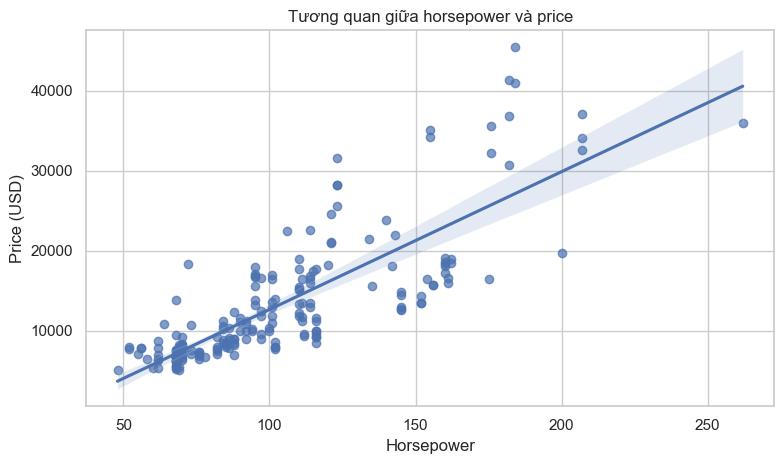

In [25]:
# TODO M2.6: biểu đồ tự chọn
# Tương quan giữa horsepower và price
plot_df = df_clean[["horsepower", "price"]].dropna(subset=["horsepower", "price"])
plt.figure(figsize=(8, 4.8))
sns.regplot(data=plot_df, x="horsepower", y="price", scatter_kws={"alpha": 0.7})
plt.title("Tương quan giữa horsepower và price")
plt.xlabel("Horsepower")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()

**Nhận xét:** 
Đồ thị cho thấy giữa horsepower và price có xu hướng tương quan dương khá rõ. Nhìn chung, các xe có horsepower cao hơn thường cũng có price cao hơn. Tuy vậy, các điểm dữ liệu không nằm sát hoàn toàn trên một đường thẳng, nên ngoài horsepower vẫn còn những yếu tố khác cũng ảnh hưởng đến giá xe
<!-- 1--2 câu -->

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

* Phần EDA với bộ dữ liệu Automobile cho price có phân phối lệch phải. Phần lớn xe nằm ở nhóm giá thấp đến trung bình, còn một số ít xe có giá rất cao tạo thành đuôi dài

* Khi so sánh theo body style, các nhóm xe có sự chênh lệch về giá. Một số kiểu thân xe như hardtop hoặc convertible thường có mức giá cao hơn trong khi hatchback và một số wagon tập trung nhiều hơn ở nhóm giá thấp và trung bình. Điều này cho thấy kiểu dáng xe có liên hệ nhất định với phân khúc giá

* Ngoài ra, engine size, horsepower và một số biến liên quan đến kích thước hoặc công suất động cơ có tương quan dương với price, nghĩa là xe có động cơ lớn hơn thường đắt hơn. Ngược lại, city_mpg và highway_mpg có xu hướng tương quan âm với price. Điều này thể hiện rằng các xe đắt hơn thường tiêu tốn nhiều nguyên liệu. Kết quả này hợp lý vì xe giá cao thường đi kèm động cơ mạnh hơn, thân xe lớn hơn và tiêu hao nhiên liệu nhiều hơn

* Trong quá trình làm sạch dữ liệu, missing values ảnh hưởng khá rõ đến phân tích, đặc biệt ở cột normalizzed losses. Vì vậy, một số phân tích có thể kém tin cậy hơn hoặc bị giảm số lượng mẫu. Ngoài ra, số lượng mẫu không quá lớn (205) và có thể chưa đại diện cho toàn bộ thị trường xe

* Về ví dụ cho việc correlation không đồng nghĩa causation là horse power tương quan dương với price nhưng điều đó không có nghĩa cứ tăng horsepower là chắc chắn làm giá xe tăng. 
Có thể cả hai cùng liên quan đến nhiều yếu tố khác như kích thước xe, thương hiệu, phân khúc hoặc trang bị xe

* Một câu hỏi có thể phân tích tiếp là trong các biến engine size, horse power, curb weight và body style, yếu tố nào ảnh hưởng mạnh nhất đến price.
<!-- Viết khoảng 150--250 từ. -->